# 🛍️ SmartCart Starter Notebook
This notebook will guide you through your group project on collaborative filtering and association rule mining for an e-commerce recommender system.

## 📥 Part 1: Data Preprocessing
Steps:
- Load `ecommerce_user_data.csv` and `product_details.csv`
- Merge data if necessary
- Create user-item matrix
- Fill missing ratings with 0
- Group user behavior by category

In [2]:
# Load data
import pandas as pd

user_data = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

print(user_data.head())
print(product_data.head())

c:\Users\kalya\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


  UserID ProductID  Rating   Timestamp  Category
0   U000     P0009       5  2024-09-08     Books
1   U000     P0020       1  2024-09-02      Home
2   U000     P0012       4  2024-10-18     Books
3   U000     P0013       1  2024-09-18  Clothing
4   U000     P0070       4  2024-09-16      Toys
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [3]:
# Cleaning data

# Standardize column names
user_data.columns = user_data.columns.str.strip()
product_data.columns = product_data.columns.str.strip()

# Remove duplicate rows based on key columns to avoid removing legitimate data
# For user_data, keep one entry per UserID-ProductID pair (take the latest timestamp if duplicates)
user_data = user_data.sort_values('Timestamp').drop_duplicates(subset=['UserID', 'ProductID'], keep='last')
# For product_data, drop exact duplicates (products should be unique by ProductID)
product_data = product_data.drop_duplicates(subset=['ProductID'], keep='first')

# Strip whitespace from text columns
for col in ["UserID", "ProductID", "Category"]:
  if col in user_data.columns:
    user_data[col] = user_data[col].astype(str).str.strip()
for col in ["ProductID", "ProductName", "Category"]:
  if col in product_data.columns:
    product_data[col] = product_data[col].astype(str).str.strip()

# Convert timestamp to datetime
user_data["Timestamp"] = pd.to_datetime(user_data["Timestamp"], errors="coerce")

# Drop rows with invalid timestamps
user_data = user_data.dropna(subset=["Timestamp"])

# Clean rating column
user_data["Rating"] = pd.to_numeric(user_data["Rating"], errors="coerce")

# Keep only valid ratings from 1 to 5
user_data = user_data[user_data["Rating"].between(1, 5)]

# Handle missing values by dropping rows missing essential IDs
user_data = user_data.dropna(subset=["UserID", "ProductID"])
product_data = product_data.dropna(subset=["ProductID", "ProductName"])

# Fill missing categories if any
user_data["Category"] = user_data["Category"].fillna("Unknown")
product_data["Category"] = product_data["Category"].fillna("Unknown")

# Standardize text formatting
user_data["Category"] = user_data["Category"].str.title()
product_data["Category"] = product_data["Category"].str.title()

print(user_data.head())
print(product_data.head())

    UserID ProductID  Rating  Timestamp Category
35    U002     P0020       1 2024-09-01     Home
179   U011     P0054       3 2024-09-01     Toys
194   U012     P0075       3 2024-09-01     Home
280   U018     P0073       2 2024-09-01   Beauty
348   U023     P0061       4 2024-09-01     Home
  ProductID      ProductName     Category
0     P0000      Toys Item 0     Clothing
1     P0001  Clothing Item 1  Electronics
2     P0002     Books Item 2  Electronics
3     P0003  Clothing Item 3  Electronics
4     P0004  Clothing Item 4  Electronics


In [4]:
# Create user-item matrix
user_item_matrix = user_data.pivot_table(index='UserID', columns='ProductID', values='Rating')
user_item_matrix_filled = user_item_matrix.fillna(0)
user_item_matrix_filled.head()

ProductID,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
UserID,,,,,,,,,,,,,,,,,,,,,
U000,0.0,0.0,0.0,3.0,0.0,5.0,0.0,3.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U001,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,5.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
U002,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
U003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
U004,0.0,3.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,4.0,3.0


In [5]:
# Aggregate user behavior by category
user_category_agg = user_data.groupby(['UserID', 'Category']).agg({'Rating': ['count', 'mean']}).reset_index()
user_category_agg.columns = ['UserID', 'Category', 'TotalInteractions', 'AverageRating']
user_category_agg.head()

,UserID,Category,TotalInteractions,AverageRating
0,U000,Books,6,3.666667
1,U000,Clothing,3,1.666667
2,U000,Electronics,3,3.666667
3,U000,Home,2,1.000000
4,U000,Toys,6,3.500000


## 🤝 Part 2: User-Based Collaborative Filtering
Steps:
- Use cosine similarity to compare users
- Recommend top-N products based on similar users
- Evaluate with Precision@K and Coverage

In [6]:
# Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(user_item_matrix_filled)
similarity_df = pd.DataFrame(similarity_matrix, index=user_item_matrix_filled.index, columns=user_item_matrix_filled.index)
similarity_df.head()

UserID,U000,U001,U002,U003,U004,U005,U006,U007,U008,U009,...,U040,U041,U042,U043,U044,U045,U046,U047,U048,U049
UserID,,,,,,,,,,,,,,,,,,,,,
U000,1.000000,0.063071,0.195522,0.023466,0.065412,0.161251,0.160096,0.092083,0.238263,0.274844,...,0.241693,0.129483,0.156790,0.132200,0.161478,0.100346,0.126917,0.150727,0.000000,0.104294
U001,0.063071,1.000000,0.190861,0.000000,0.111332,0.009540,0.000000,0.172286,0.167460,0.017593,...,0.121540,0.024075,0.097953,0.007821,0.000000,0.000000,0.193670,0.247805,0.000000,0.000000
U002,0.195522,0.190861,1.000000,0.065094,0.111662,0.050830,0.027756,0.055877,0.000000,0.181229,...,0.144756,0.000000,0.217465,0.000000,0.055992,0.034794,0.194243,0.110030,0.177165,0.000000
U003,0.023466,0.000000,0.065094,1.000000,0.035737,0.104116,0.026650,0.000000,0.025384,0.288009,...,0.243836,0.000000,0.000000,0.074688,0.197121,0.000000,0.054396,0.126773,0.374228,0.250000
U004,0.065412,0.111332,0.111662,0.035737,1.000000,0.159064,0.057144,0.026294,0.195942,0.247023,...,0.062741,0.116202,0.078797,0.048044,0.103747,0.133716,0.124969,0.217464,0.255318,0.172729


In [7]:
# Count ratings per user
user_rating_counts = (user_item_matrix_filled > 0).sum(axis=1)
print("Top 5 users with most ratings:")
print(user_rating_counts.nlargest(5))
print("Bottom 5 users with least ratings:")
print(user_rating_counts.nsmallest(5))

Top 5 users with most ratings:
UserID
U000    20
U008    20
U035    20
U009    19
U010    19
dtype: int64
Bottom 5 users with least ratings:
UserID
U005    10
U014    10
U021    10
U025    10
U034    10
dtype: int64


In [8]:
# Create recommendation function
# Find most similar user, recommend products they rated highly that target user hasn’t rated

import numpy as np

# Create product to category mapping
product_to_category = product_data.set_index('ProductID')['Category'].to_dict()

def get_user_recommendations(user_id, user_item_matrix_filled, similarity_df, user_category_agg, top_n=10, num_similar_users=20, min_rating=3, use_categories=True, verbose=True):
    """
    Generate user-based collaborative filtering recommendations.
    
    Modes:
    - Hybrid CF (use_categories=True): Recommends products from user's preferred categories only.
      Preferred categories are those with average rating >= 3.5. This personalizes recommendations
      but may limit diversity (e.g., no cross-category suggestions).
    - Pure CF (use_categories=False): Recommends products from ANY category if similar users liked them.
      This is standard user-based CF, allowing serendipitous discoveries but potentially less relevant.
    
    Steps:
    1. Find top similar users via cosine similarity.
    2. Collect unrated products rated >= min_rating by similar users.
    3. Filter by category (if hybrid) or allow all (if pure).
    4. Weight by similarity scores and rank by weighted average rating.
    """
    if user_id not in similarity_df.index:
        if verbose:
            print(f"User {user_id} not found in similarity matrix.")
        return []
    
    # Get user's preferred categories (average rating >= 3.5) - only for hybrid mode
    if use_categories:
        user_cats = user_category_agg[(user_category_agg['UserID'] == user_id) & (user_category_agg['AverageRating'] >= 3)]['Category'].tolist()
        if verbose:
            print(f"User {user_id} preferred categories (hybrid mode): {user_cats}")
            if not user_cats:
                print(f"Warning: No preferred categories for {user_id}. No recommendations possible in hybrid mode.")
    else:
        user_cats = list(set(product_to_category.values()))  # all unique categories
        if verbose:
            print(f"User {user_id} using all categories (pure CF mode - no category filter).")
    
    # Get similarity scores
    sim_scores = similarity_df.loc[user_id].drop(user_id).sort_values(ascending=False)
    if verbose:
        print(f"Top {num_similar_users} similar users for {user_id}: {sim_scores.head(num_similar_users).index.tolist()}")
    
    # Top similar users
    top_similar_users = sim_scores.head(num_similar_users).index
    
    # Products the user has rated
    user_rated_products = user_item_matrix_filled.loc[user_id][user_item_matrix_filled.loc[user_id] > 0].index
    if verbose:
        print(f"User {user_id} has rated {len(user_rated_products)} products.")
    
    # Collect recommendations
    recommendations = {}
    
    for similar_user in top_similar_users:
        similar_user_ratings = user_item_matrix_filled.loc[similar_user]
        for product in user_item_matrix_filled.columns:
            rating = similar_user_ratings[product]
            if rating >= min_rating and product not in user_rated_products:
                product_cat = product_to_category.get(product, 'Unknown')
                if product_cat in user_cats:
                    if product not in recommendations:
                        recommendations[product] = []
                    recommendations[product].append((rating, sim_scores.loc[similar_user]))
    
    if verbose:
        print(f"Collected {len(recommendations)} potential recommendations for {user_id}.")
        if use_categories and not user_cats:
            print("In hybrid mode, empty preferred categories blocked all recommendations.")
        elif not use_categories:
            print("In pure CF mode, recommendations span all categories for maximum diversity.")
    
    # Compute weighted average rating for each recommended product
    final_recommendations = {}
    for product, ratings_weights in recommendations.items():
        if not ratings_weights:
            continue
        ratings, weights = zip(*ratings_weights)
        weighted_avg = np.average(ratings, weights=weights)
        final_recommendations[product] = weighted_avg
    
    # Sort by weighted average and return top_n
    sorted_recs = sorted(final_recommendations.items(), key=lambda x: x[1], reverse=True)[:top_n]
    if verbose:
        print(f"Top {top_n} recommendations for {user_id}: {[p for p, s in sorted_recs]}")
        if use_categories:
            print("Hybrid mode: Recommendations personalized to user's category preferences.")
        else:
            print("Pure CF mode: Recommendations based solely on user similarity, ignoring categories.")
    return [product for product, score in sorted_recs]

# Example: Get recommendations for a user
example_user = user_item_matrix_filled.index[35]
recommendations = get_user_recommendations(example_user, user_item_matrix_filled, similarity_df, user_category_agg)

User U035 preferred categories (hybrid mode): ['Beauty', 'Books', 'Home', 'Toys']
Top 20 similar users for U035: ['U012', 'U029', 'U032', 'U006', 'U016', 'U004', 'U034', 'U015', 'U030', 'U018', 'U014', 'U011', 'U037', 'U049', 'U047', 'U026', 'U008', 'U013', 'U025', 'U031']
User U035 has rated 20 products.
Collected 44 potential recommendations for U035.
Top 10 recommendations for U035: ['P0020', 'P0046', 'P0061', 'P0095', 'P0005', 'P0041', 'P0007', 'P0073', 'P0071', 'P0042']
Hybrid mode: Recommendations personalized to user's category preferences.


In [9]:
# Implement evaluation metrics like Precision@K and Coverage
# Example: compare recommended vs actual rated items

from sklearn.model_selection import train_test_split

def evaluate_recommendations(user_item_matrix_filled, user_category_agg, k=5, test_size=0.2, use_categories=True):
    mode = "Hybrid CF" if use_categories else "Pure CF"
    print(f"Evaluating {mode} (use_categories={use_categories})")
    precision_scores = []
    recall_scores = []
    coverage = set()
    
    for user_id in user_item_matrix_filled.index:
        # Get user's ratings (non-zero)
        user_ratings = user_item_matrix_filled.loc[user_id][user_item_matrix_filled.loc[user_id] > 0]
        if len(user_ratings) < 2:
            continue  # Skip users with too few ratings
        
        # Split into train and test
        rated_products = user_ratings.index.tolist()
        train_products, test_products = train_test_split(rated_products, test_size=test_size, random_state=42)
        
        # Create train matrix (mask test products by setting to 0)
        train_matrix = user_item_matrix_filled.copy()
        for prod in test_products:
            train_matrix.loc[user_id, prod] = 0
        
        # Recompute similarity on train
        train_similarity_matrix = cosine_similarity(train_matrix)
        train_similarity_df = pd.DataFrame(train_similarity_matrix, index=train_matrix.index, columns=train_matrix.index)
        
        # Get recommendations
        recommendations = get_user_recommendations(user_id, train_matrix, train_similarity_df, user_category_agg, top_n=k, use_categories=use_categories, verbose=False)
        
        # Evaluate
        relevant = set(test_products)
        recommended = set(recommendations)
        coverage.update(recommended)
        
        if len(recommended) > 0:
            precision = len(relevant & recommended) / len(recommended)
            precision_scores.append(precision)
        
        if len(relevant) > 0:
            recall = len(relevant & recommended) / len(relevant)
            recall_scores.append(recall)
    
    avg_precision = np.mean(precision_scores) if precision_scores else 0
    avg_recall = np.mean(recall_scores) if recall_scores else 0
    coverage_ratio = len(coverage) / len(user_item_matrix_filled.columns)
    
    print(f"Average Precision@{k}: {avg_precision:.3f}")
    print(f"Average Recall@{k}: {avg_recall:.3f}")
    print(f"Coverage: {coverage_ratio:.3f}")
    
    return avg_precision, avg_recall, coverage_ratio

# Run evaluation for Hybrid CF
print("Hybrid CF Evaluation:")
evaluate_recommendations(user_item_matrix_filled, user_category_agg, k=5, use_categories=True)

print("\n" + "="*50)

# Run evaluation for Pure CF
print("Pure CF Evaluation:")
evaluate_recommendations(user_item_matrix_filled, user_category_agg, k=5, use_categories=False)

Hybrid CF Evaluation:
Evaluating Hybrid CF (use_categories=True)
Average Precision@5: 0.029
Average Recall@5: 0.042
Coverage: 0.650

Pure CF Evaluation:
Evaluating Pure CF (use_categories=False)
Average Precision@5: 0.024
Average Recall@5: 0.035
Coverage: 0.570


(np.float64(0.024000000000000004), np.float64(0.034999999999999996), 0.57)

In [10]:
# Show top-5 recommendations for a few users
sample_users = user_item_matrix_filled.index[:5]
for user in sample_users:
    recs = get_user_recommendations(user, user_item_matrix_filled, similarity_df, user_category_agg, top_n=10)
    print(f"Recommendations for {user}: {recs} \n")

User U000 preferred categories (hybrid mode): ['Books', 'Electronics', 'Toys']
Top 20 similar users for U000: ['U028', 'U010', 'U018', 'U009', 'U029', 'U024', 'U013', 'U040', 'U008', 'U002', 'U039', 'U037', 'U038', 'U044', 'U005', 'U006', 'U023', 'U026', 'U042', 'U047']
User U000 has rated 20 products.
Collected 38 potential recommendations for U000.
Top 10 recommendations for U000: ['P0094', 'P0045', 'P0095', 'P0034', 'P0039', 'P0029', 'P0008', 'P0064', 'P0030', 'P0002']
Hybrid mode: Recommendations personalized to user's category preferences.
Recommendations for U000: ['P0094', 'P0045', 'P0095', 'P0034', 'P0039', 'P0029', 'P0008', 'P0064', 'P0030', 'P0002'] 

User U001 preferred categories (hybrid mode): ['Beauty', 'Electronics', 'Toys']
Top 20 similar users for U001: ['U012', 'U027', 'U017', 'U022', 'U047', 'U029', 'U015', 'U016', 'U018', 'U032', 'U011', 'U046', 'U002', 'U024', 'U037', 'U036', 'U007', 'U008', 'U026', 'U031']
User U001 has rated 13 products.
Collected 37 potential re

In [11]:
# Compare Hybrid vs Pure CF for a few users
print("\n" + "="*50)
print("COMPARISON: Hybrid CF vs Pure CF")
print("="*50)

comparison_users = user_item_matrix_filled.index[:3]  # First 3 users for brevity
for user in comparison_users:
    print(f"\nUser {user}:")
    
    # Hybrid CF (with category filter)
    hybrid_recs = get_user_recommendations(user, user_item_matrix_filled, similarity_df, user_category_agg, top_n=5, use_categories=True, verbose=False)
    print(f"  Hybrid CF (category-filtered): {hybrid_recs}")
    
    # Pure CF (no category filter)
    pure_recs = get_user_recommendations(user, user_item_matrix_filled, similarity_df, user_category_agg, top_n=5, use_categories=False, verbose=False)
    print(f"  Pure CF (no filter): {pure_recs}")
    
    # Highlight differences
    hybrid_set = set(hybrid_recs)
    pure_set = set(pure_recs)
    unique_hybrid = hybrid_set - pure_set
    unique_pure = pure_set - hybrid_set
    if unique_hybrid:
        print(f"    Unique to Hybrid: {list(unique_hybrid)}")
    if unique_pure:
        print(f"    Unique to Pure: {list(unique_pure)}")
    if not unique_hybrid and not unique_pure:
        print("    Same recommendations (or both empty).")


COMPARISON: Hybrid CF vs Pure CF

User U000:
  Hybrid CF (category-filtered): ['P0094', 'P0045', 'P0095', 'P0034', 'P0039']
  Pure CF (no filter): ['P0032', 'P0062', 'P0094', 'P0075', 'P0072']
    Unique to Hybrid: ['P0034', 'P0095', 'P0039', 'P0045']
    Unique to Pure: ['P0075', 'P0072', 'P0032', 'P0062']

User U001:
  Hybrid CF (category-filtered): ['P0005', 'P0046', 'P0073', 'P0087', 'P0004']
  Pure CF (no filter): ['P0005', 'P0046', 'P0061', 'P0007', 'P0000']
    Unique to Hybrid: ['P0004', 'P0073', 'P0087']
    Unique to Pure: ['P0061', 'P0000', 'P0007']

User U002:
  Hybrid CF (category-filtered): ['P0032', 'P0073', 'P0092', 'P0078', 'P0089']
  Pure CF (no filter): ['P0048', 'P0034', 'P0039', 'P0000', 'P0032']
    Unique to Hybrid: ['P0089', 'P0073', 'P0078', 'P0092']
    Unique to Pure: ['P0000', 'P0048', 'P0039', 'P0034']


In [12]:
# Show top-5 recommendations for a few users (Pure CF)
sample_users = user_item_matrix_filled.index[:5]
for user in sample_users:
    recs = get_user_recommendations(user, user_item_matrix_filled, similarity_df, user_category_agg, top_n=5, use_categories=False, verbose=False)
    print(f"Pure CF Recommendations for {user}: {recs}")

Pure CF Recommendations for U000: ['P0032', 'P0062', 'P0094', 'P0075', 'P0072']
Pure CF Recommendations for U001: ['P0005', 'P0046', 'P0061', 'P0007', 'P0000']
Pure CF Recommendations for U002: ['P0048', 'P0034', 'P0039', 'P0000', 'P0032']
Pure CF Recommendations for U003: ['P0017', 'P0025', 'P0083', 'P0021', 'P0041']
Pure CF Recommendations for U004: ['P0024', 'P0005', 'P0041', 'P0049', 'P0032']


## 🔍 Part 3: Association Rule Mining (Apriori)
Steps:
- Convert user-product interactions to transaction format
- Apply Apriori algorithm to find frequent itemsets
- Generate association rules (support, confidence, lift)

In [13]:
# Convert to transaction format
from mlxtend.preprocessing import TransactionEncoder
from IPython.display import display
# Map product IDs to human-readable names for rule interpretation
product_lookup = product_data.set_index('ProductID')['ProductName'].to_dict()
# Build one basket per user from their purchased products
transactions = (
    user_data.groupby('UserID')['ProductID']
    .apply(lambda products: sorted(set(products.dropna().astype(str))))
    .tolist()
)
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Built {len(transactions)} transactions from {user_data['UserID'].nunique()} users and {df_trans.shape[1]} unique products.")
df_trans.head()

Built 50 transactions from 50 users and 100 unique products.


,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,...,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
0,False,False,False,True,False,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,True,True


In [14]:
# Apply Apriori and generate rules
from mlxtend.frequent_patterns import apriori, association_rules
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.5
def format_itemset(itemset):
    return ', '.join(product_lookup.get(pid, pid) for pid in sorted(itemset))
frequent_itemsets = apriori(df_trans, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets['itemset_size'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets['items'] = frequent_itemsets['itemsets'].apply(format_itemset)
print(f"Frequent itemsets found: {len(frequent_itemsets)}")
display(
    frequent_itemsets
    .sort_values(['support', 'itemset_size'], ascending=[False, True])
    .head(10)[['items', 'support', 'itemset_size']]
)
if frequent_itemsets.empty or frequent_itemsets['itemsets'].map(len).max() < 2:
    raise ValueError('Apriori did not find any itemsets of size 2 or larger; lower MIN_SUPPORT.')
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=MIN_CONFIDENCE)
rules['antecedents_str'] = rules['antecedents'].apply(format_itemset)
rules['consequents_str'] = rules['consequents'].apply(format_itemset)
rules = rules.sort_values(['lift', 'confidence', 'support'], ascending=False).reset_index(drop=True)
print(f"Association rules found: {len(rules)}")
display(rules.head(10)[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']])

Frequent itemsets found: 612


,items,support,itemset_size
69,Beauty Item 70,0.34,1
50,Home Item 51,0.26,1
88,Clothing Item 89,0.26,1
42,Books Item 43,0.24,1
87,Clothing Item 88,0.24,1
4,Clothing Item 4,0.22,1
29,Books Item 30,0.22,1
43,Clothing Item 44,0.22,1
64,Toys Item 65,0.22,1
76,Home Item 77,0.22,1


Association rules found: 527


,antecedents_str,consequents_str,support,confidence,lift
0,"Books Item 11, Beauty Item 50","Books Item 6, Home Item 52",0.06,1.0,16.666667
1,"Books Item 6, Books Item 11","Beauty Item 50, Home Item 52",0.06,1.0,16.666667
2,"Beauty Item 50, Home Item 52","Books Item 6, Books Item 11",0.06,1.0,16.666667
3,"Books Item 6, Home Item 52","Books Item 11, Beauty Item 50",0.06,1.0,16.666667
4,"Clothing Item 13, Clothing Item 88","Clothing Item 44, Electronics Item 64",0.06,1.0,16.666667
5,"Clothing Item 44, Electronics Item 64","Clothing Item 13, Clothing Item 88",0.06,1.0,16.666667
6,"Home Item 79, Clothing Item 88","Clothing Item 13, Electronics Item 64",0.06,1.0,16.666667
7,"Clothing Item 13, Electronics Item 64","Home Item 79, Clothing Item 88",0.06,1.0,16.666667
8,"Home Item 79, Clothing Item 88","Clothing Item 44, Electronics Item 64",0.06,1.0,16.666667
9,"Clothing Item 44, Electronics Item 64","Home Item 79, Clothing Item 88",0.06,1.0,16.666667


## 📊 Part 4: Visualization
Steps:
- Plot the strongest frequent itemsets
- Plot the strongest association rules
- Visualize user similarity and other notebook insights

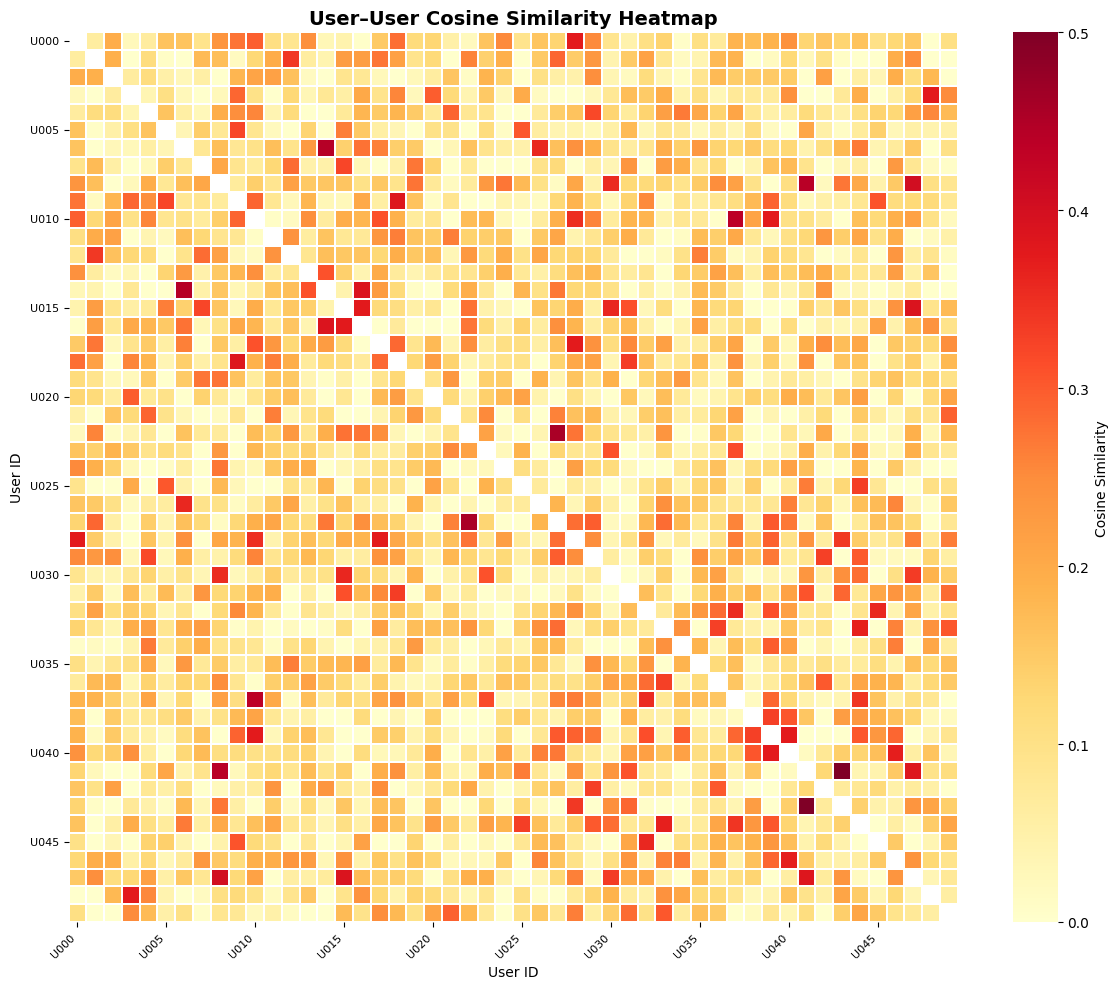

Heatmap saved as part4_heatmap.png


In [15]:
# ── User Similarity Heatmap ─────────────────

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))

# Mask diagonal (self similarity = 1)
mask = np.eye(len(similarity_df), dtype=bool)

sns.heatmap(
    similarity_df,
    cmap='YlOrRd',
    mask=mask,
    vmin=0, vmax=0.5,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Cosine Similarity'}
)

plt.title('User–User Cosine Similarity Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('User ID')
plt.ylabel('User ID')

# Show limited ticks for readability
n_users = len(similarity_df)
tick_positions = list(range(0, n_users, 5))
tick_labels = [similarity_df.index[i] for i in tick_positions]

plt.xticks([p + 0.5 for p in tick_positions], tick_labels, rotation=45, ha='right', fontsize=8)
plt.yticks([p + 0.5 for p in tick_positions], tick_labels, fontsize=8)

plt.tight_layout()
plt.savefig('part4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Heatmap saved as part4_heatmap.png')

In [16]:
# ── Top-5 Recommendations ───────────────

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# --- Generate top-5 recommendations for every user ---
all_users = user_item_matrix_filled.index.tolist()
rec_rows = []

for uid in all_users:
    recs = get_user_recommendations(
        uid, user_item_matrix_filled, similarity_df,
        user_category_agg, top_n=5, use_categories=True, verbose=False
    )
    
    rec_names = [product_lookup.get(pid, pid) for pid in recs]
    rec_cats  = [product_to_category.get(pid, 'Unknown') for pid in recs]
    
    for rank, (pid, name, cat) in enumerate(zip(recs, rec_names, rec_cats), start=1):
        rec_rows.append({
            'UserID'      : uid,
            'Rank'        : rank,
            'ProductID'   : pid,
            'ProductName' : name,
            'Category'    : cat
        })

rec_df = pd.DataFrame(rec_rows)

# --- Save output ---
rec_df.to_csv('smartcart_recommendations.csv', index=False)
print(f'Recommendations CSV saved: smartcart_recommendations.csv')

# --- Display per-user recommendations ---
rec_wide = rec_df.pivot_table(
    index='UserID', columns='Rank', values='ProductName', aggfunc='first'
).rename(columns={i: f'Rec #{i}' for i in range(1, 6)})

rec_wide.columns.name = None

print('\nTop-5 Recommendations per User (sample):')
display(rec_wide.head(10))


# ── USER GROUP RECOMMENDATIONS ─────────────────────────

user_category = user_category_agg.pivot_table(
    index='UserID',
    columns='Category',
    values='AverageRating',
    fill_value=0
)

# Assign each user to dominant category
user_groups = user_category.idxmax(axis=1)
user_groups_df = pd.DataFrame(user_groups, columns=['Group'])

# Merge with recommendations
rec_with_groups = rec_df.merge(user_groups_df, on='UserID')

# Group recommendations
group_recommendations = rec_with_groups.groupby('Group')['ProductName'].apply(list)

print('\n📊 Top Recommendations per User Group:')
for group, recs in group_recommendations.items():
    print(f"\nGroup: {group}")
    print(recs[:5])

Recommendations CSV saved: smartcart_recommendations.csv

Top-5 Recommendations per User (sample):


,Rec #1,Rec #2,Rec #3,Rec #4,Rec #5
UserID,,,,,
U000,Toys Item 94,Electronics Item 45,Toys Item 95,Beauty Item 34,Toys Item 39
U001,Home Item 5,Home Item 46,Toys Item 73,Beauty Item 87,Clothing Item 4
U002,Toys Item 32,Toys Item 73,Home Item 92,Toys Item 78,Clothing Item 89
U003,Beauty Item 83,Toys Item 73,Toys Item 49,Toys Item 95,Toys Item 22
U004,Beauty Item 24,Home Item 5,Home Item 54,Home Item 76,Beauty Item 17
U005,Beauty Item 17,Home Item 5,Home Item 46,Beauty Item 70,Clothing Item 97
U006,Beauty Item 17,Clothing Item 75,Books Item 37,Books Item 29,Home Item 5
U007,Clothing Item 61,Electronics Item 45,Beauty Item 17,Clothing Item 91,Books Item 41
U008,Beauty Item 34,Home Item 5,Electronics Item 48,Home Item 46,Clothing Item 91



📊 Top Recommendations per User Group:

Group: Beauty
['Home Item 5', 'Home Item 46', 'Toys Item 73', 'Beauty Item 87', 'Clothing Item 4']

Group: Books
['Toys Item 94', 'Electronics Item 45', 'Toys Item 95', 'Beauty Item 34', 'Toys Item 39']

Group: Clothing
['Beauty Item 24', 'Home Item 5', 'Home Item 54', 'Home Item 76', 'Beauty Item 17']

Group: Electronics
['Clothing Item 61', 'Electronics Item 45', 'Beauty Item 17', 'Clothing Item 91', 'Books Item 41']

Group: Home
['Beauty Item 17', 'Clothing Item 75', 'Books Item 37', 'Books Item 29', 'Home Item 5']

Group: Toys
['Beauty Item 17', 'Home Item 5', 'Home Item 46', 'Beauty Item 70', 'Clothing Item 97']


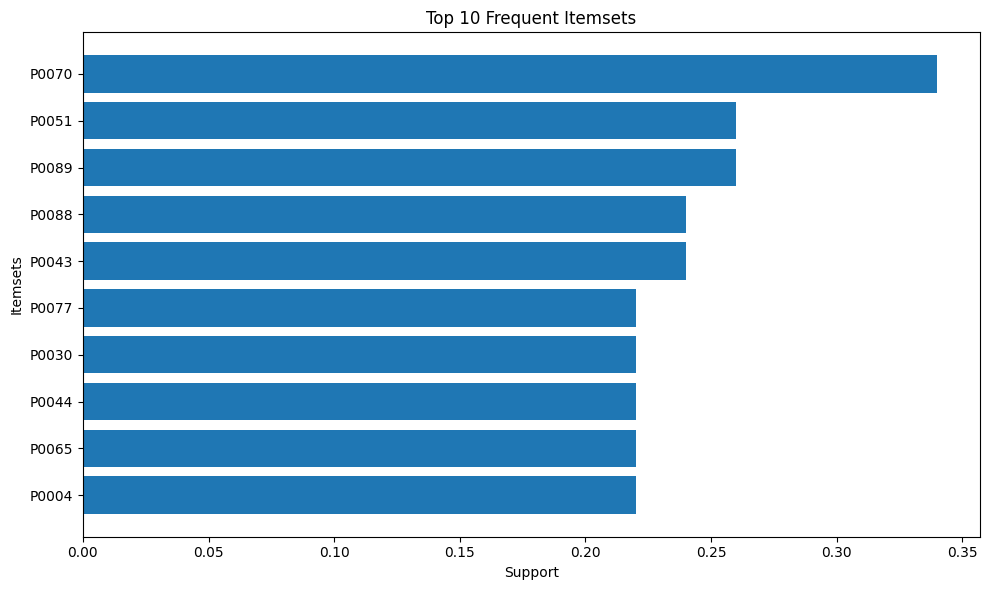

In [17]:
import matplotlib.pyplot as plt

# Sort and take top 10 frequent itemsets
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

# Convert frozenset to string for readability
top_itemsets['itemsets_str'] = top_itemsets['itemsets'].apply(lambda x: ', '.join(list(x)))

plt.figure(figsize=(10,6))
plt.barh(top_itemsets['itemsets_str'], top_itemsets['support'])
plt.xlabel('Support')
plt.ylabel('Itemsets')
plt.title('Top 10 Frequent Itemsets')
plt.gca().invert_yaxis()  # Highest at top
plt.tight_layout()
plt.show()

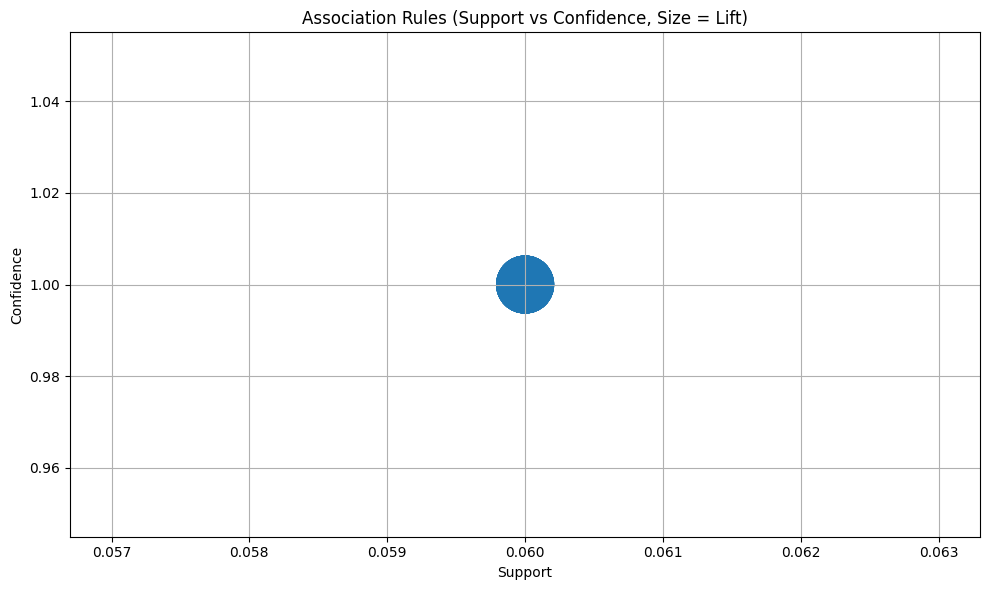

In [18]:
import matplotlib.pyplot as plt

# Take strongest rules (top 20 by lift)
top_rules = rules.sort_values(by='lift', ascending=False).head(20)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    top_rules['support'], 
    top_rules['confidence'], 
    s=top_rules['lift'] * 100,  # size based on lift
    alpha=0.6
)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules (Support vs Confidence, Size = Lift)')

plt.grid(True)
plt.tight_layout()
plt.show()

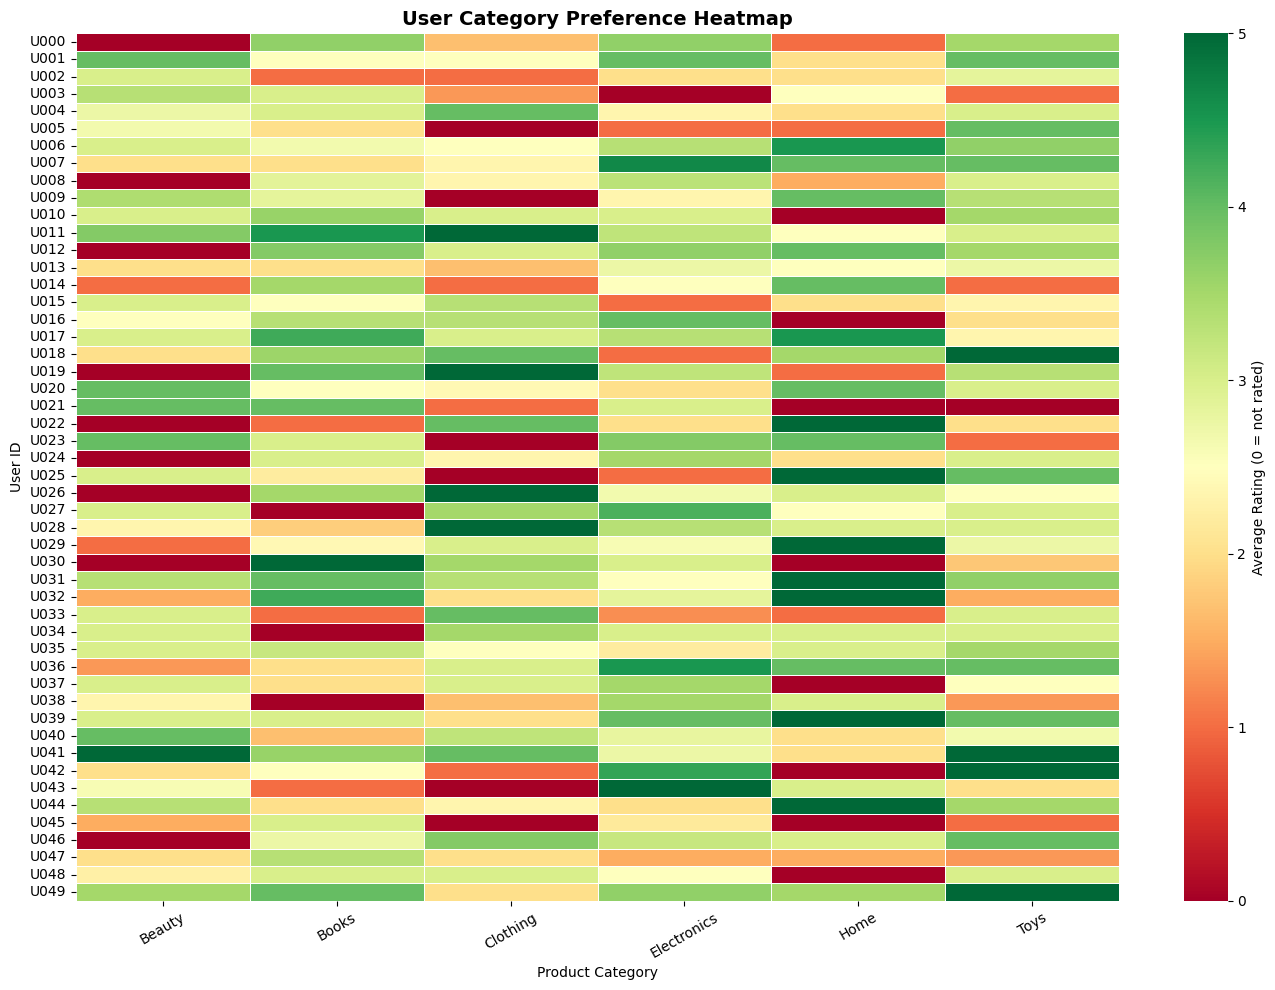

Category preference heatmap saved as part4_cat_preference.png


In [19]:
# ──  Category Preference Heatmap ──────────

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot: rows = users, columns = categories
cat_pivot = user_category_agg.pivot_table(
    index='UserID', columns='Category',
    values='AverageRating', fill_value=0
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cat_pivot,
    cmap='RdYlGn',
    vmin=0, vmax=5,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Average Rating (0 = not rated)'}
)

plt.title('User Category Preference Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('User ID')

plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('part4_cat_preference.png', dpi=150, bbox_inches='tight')
plt.show()

print('Category preference heatmap saved as part4_cat_preference.png')

## 🧠 Part 5: Conceptual Questions
Answer the following questions in your report:
1. How does data sparsity affect performance?
2. What kinds of product bundles were discovered?
3. What improvements would you suggest for real-world deployment?